In [ ]:

**Goal:** Represent quantum dot device configurations as DAGs where:
- **Nodes** = quantum dot sites (source, plunger gates, dot regions, drain)
- **Directed edges** = electron / signal flow (source → dot → drain)
- **Edge weights** = tunnel coupling strength (current gradient at block boundary)
- **Node attributes** = charge state, sensor reading, current, gate type 



In [1]:
import networkx as nx, torch, torch_geometric
print(f"NetworkX : {nx.__version__}")
print(f"PyTorch  : {torch.__version__}")
print(f"PyG      : {torch_geometric.__version__}")

C:\Users\Lehma\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


NetworkX : 3.1
PyTorch  : 2.1.2+cpu
PyG      : 2.7.0


In [2]:
import os, time, warnings, random, math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from collections import Counter, defaultdict

import networkx as nx
from scipy.ndimage import label as scipy_label

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as GeoLoader
from torch_geometric.nn import global_mean_pool, global_max_pool

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 10})

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


In [9]:
DATA_DIR = Path(r"C:/Users/Lehma/AIProjects/data_qflow_lite")
OUT_DIR  = Path(r"C:/Users/Lehma/AIProjects/data_qflow_lite/dag_results")
OUT_DIR.mkdir(parents=True, exist_ok=True)

LABEL_NAMES = {0: "Barrier", 1: "Single Dot",
               2: "Double Dot"}
N_CLASSES   = 3
ALL_LABELS  = sorted(LABEL_NAMES.keys())
CLASS_NAMES = [LABEL_NAMES[k] for k in ALL_LABELS]

# DAG construction
GRID_N       = 10      # 10x10 = 100 nodes per device
COUPLING_THR = 0.05    # min normalised coupling to add edge
MAX_SKIP     = 1       # allow long-range (skip-1) forward edges

# GNN
HIDDEN_DIM = 64;  N_LAYERS = 3;  DROPOUT = 0.3
BATCH_SIZE = 32;  N_EPOCHS = 100; LR = 3e-3; TEST_SIZE = 0.20

NODE_TYPES  = {"source":0, "dot":1, "barrier":2, "drain":3, "sensor":4}
NODE_COLORS = {"source":"#27ae60","dot":"#2a9d8f","barrier":"#e9c46a",
               "drain":"#e63946","sensor":"#9b59b6"}
PALETTE     = ["#e63946","#2a9d8f","#e9c46a","#457b9d"]

print(f"Grid: {GRID_N}x{GRID_N} = {GRID_N**2} nodes/device")

Grid: 10x10 = 100 nodes/device


In [10]:
def charge_to_float(c):
    try: return float(len(c)) if hasattr(c,'__len__') else float(c)
    except: return 0.0

def load_dataset(data_dir):
    files = sorted([f for f in os.listdir(data_dir)
                    if f.endswith('.npy') and not f.startswith('.')])
    currents, coulombs, occupancies, pixel_states_all, labels = [],[],[],[],[]
    skipped = 0
    for fname in files:
        try:
            raw = np.load(data_dir / fname, allow_pickle=True).item()
            out = raw['output']
            if len(out) != 10000: skipped+=1; continue
            cur = np.array([p['current'] for p in out],
                           dtype=np.float32).reshape(100,100)
            sen = np.array([p['sensor'][0] if hasattr(p['sensor'],'__len__')
                            else float(p['sensor']) for p in out],
                           dtype=np.float32).reshape(100,100)
            chg = np.array([charge_to_float(p['charge']) for p in out],
                           dtype=np.float32).reshape(100,100)
            pst = np.array([p['state'] for p in out],
                           dtype=np.int64).reshape(100,100)
            states = [p['state'] for p in out]
            label  = int(max(set(states), key=states.count))
            currents.append(cur); coulombs.append(sen)
            occupancies.append(chg); pixel_states_all.append(pst)
            labels.append(label)
        except: skipped+=1
    if skipped: print(f"Skipped {skipped} files.")
    return (np.stack(currents).astype(np.float32),
            np.stack(coulombs).astype(np.float32),
            np.stack(occupancies).astype(np.float32),
            np.stack(pixel_states_all).astype(np.int64),
            np.array(labels, dtype=np.int64))

print("Loading dataset")
current, coulomb, occupancy, pixel_states, labels = load_dataset(DATA_DIR)
print(f"Loaded {len(labels)} samples")
print("\\nClass distribution:")
for k,name in LABEL_NAMES.items():
    n=(labels==k).sum(); bar="█"*int(n/len(labels)*40)
    print(f"  {name:<14} ({k})  {n:>4}  {bar}")

Loading dataset
Loaded 1001 samples
\nClass distribution:
  Barrier        (0)    18  
  Single Dot     (1)   756  ██████████████████████████████
  Double Dot     (2)   227  █████████


In [11]:
def classify_node_type(row, col, grid_n, blk_state, blk_charge):
    if col == 0:
        return "source"
    if col == grid_n - 1:
        return "drain"
    if (row == 0 or row == grid_n-1) and blk_charge > 0.5: 
        return "sensor"
    if blk_state == 0:      
        return "barrier"
    return "dot"

def compute_coupling(cur_map, r1, c1, r2, c2, grid_n):
    bh = bw = 100 // grid_n
    if c2 == c1+1:
        bnd = cur_map[r1*bh:(r1+1)*bh, (c1+1)*bw-2:(c1+1)*bw+2]
    elif r2 == r1+1:
        bnd = cur_map[(r1+1)*bh-2:(r1+1)*bh+2, c1*bw:(c1+1)*bw]
    else:
        bnd = cur_map[r1*bh:(r1+1)*bh, c1*bw:(c1+1)*bw]
    return float(np.log1p(np.abs(bnd)).mean())


In [12]:
def build_dag(idx, cur_map, cou_map, chg_map, pst_map,
              grid_n=GRID_N, coupling_thr=COUPLING_THR, max_skip=MAX_SKIP):
    G  = nx.DiGraph()
    bh = bw = 100 // grid_n
    cur_max = np.log1p(np.abs(cur_map)).max() + 1e-8

    for r in range(grid_n):
        for c in range(grid_n):
            nid = r*grid_n + c
            rs,re,cs,ce = r*bh,(r+1)*bh,c*bw,(c+1)*bw
            cur_blk = cur_map[rs:re,cs:ce]
            cou_blk = cou_map[rs:re,cs:ce]
            chg_blk = chg_map[rs:re,cs:ce]
            pst_blk = pst_map[rs:re,cs:ce]
            valid   = [s for s in pst_blk.flatten().tolist() if s in LABEL_NAMES]
            blk_st  = int(max(set(valid),key=valid.count)) if valid else 0
            blk_chg = float(chg_blk.mean())
            ntype   = classify_node_type(r,c,grid_n,blk_st,blk_chg)
            G.add_node(nid, row=r, col=c, layer=c,
                       norm_row=r/max(grid_n-1,1), norm_col=c/max(grid_n-1,1),
                       type=ntype, type_id=NODE_TYPES[ntype], state=blk_st,
                       current_mean=float(np.log1p(np.abs(cur_blk)).mean()),
                       current_std =float(np.log1p(np.abs(cur_blk)).std()),
                       sensor_mean =float(cou_blk.mean()),
                       charge_mean =blk_chg)

    for r in range(grid_n):
        for c in range(grid_n):
            src = r*grid_n + c
            for skip in range(1, max_skip+2):
                dc = c+skip
                if dc >= grid_n: break
                dst = r*grid_n + dc
                w   = compute_coupling(cur_map,r,c,r,dc,grid_n) / cur_max
                if w >= coupling_thr:
                    G.add_edge(src,dst,weight=float(w),
                               edge_type="forward",skip_distance=skip)
            for dr in [-1,1]:
                nr,nc = r+dr, c+1
                if 0<=nr<grid_n and nc<grid_n:
                    dst = nr*grid_n+nc
                    w   = compute_coupling(cur_map,r,c,nr,nc,grid_n)/cur_max
                    if w >= coupling_thr:
                        G.add_edge(src,dst,weight=float(w),
                                   edge_type="lateral",skip_distance=1)

    assert nx.is_directed_acyclic_graph(G), "Cycle detected!"
    return G

print("Building DAGs")
t0 = time.time()
dag_list = [build_dag(i,current[i],coulomb[i],occupancy[i],pixel_states[i])
            for i in range(len(labels))]
print(f"Built {len(dag_list)} DAGs in {time.time()-t0:.1f}s")
g0 = dag_list[0]
print(f"Example: nodes={g0.number_of_nodes()} edges={g0.number_of_edges()}")
print(f"  Is DAG         : {nx.is_directed_acyclic_graph(g0)}")
print(f"  Critical path  : {len(nx.dag_longest_path(g0))} hops")
print(f"  Node types     : {Counter(nx.get_node_attributes(g0,'type').values())}")

Building DAGs
Built 1001 DAGs in 20.6s
Example: nodes=100 edges=65
  Is DAG         : True
  Critical path  : 7 hops
  Node types     : Counter({'dot': 49, 'sensor': 16, 'barrier': 15, 'source': 10, 'drain': 10})


In [13]:
def analyse_dag(G):
    lp   = nx.dag_longest_path(G)
    lpw  = nx.dag_longest_path_length(G, weight='weight')
    lays = Counter(nx.get_node_attributes(G,'layer').values())
    wts  = [d['weight'] for _,_,d in G.edges(data=True)]
    return {
        'longest_path'        : lp,
        'critical_path_len'   : len(lp),
        'critical_path_weight': float(lpw),
        'dag_width'           : max(lays.values()),
        'n_sources': len([n for n in G if G.in_degree(n)==0]),
        'n_sinks'  : len([n for n in G if G.out_degree(n)==0]),
        'mean_coupling': float(np.mean(wts)) if wts else 0.0,
        'max_coupling' : float(np.max(wts))  if wts else 0.0,
        'max_out_degree': max(dict(G.out_degree()).values()),
    }

print("DAG Topology per Class")
print("="*65)
for cls_idx in ALL_LABELS:
    idx = int(np.where(labels==cls_idx)[0][0])
    m   = analyse_dag(dag_list[idx])
    print(f"  {LABEL_NAMES[cls_idx]}")
    print(f"    Edges={dag_list[idx].number_of_edges()}  "
          f"CritPath={m['critical_path_len']}hops  "
          f"Width={m['dag_width']}  "
          f"MeanCoupling={m['mean_coupling']:.4f}")

DAG Topology per Class
  Barrier
    Edges=82  CritPath=7hops  Width=10  MeanCoupling=0.1327
  Single Dot
    Edges=65  CritPath=7hops  Width=10  MeanCoupling=0.1299
  Double Dot
    Edges=61  CritPath=6hops  Width=10  MeanCoupling=0.1071


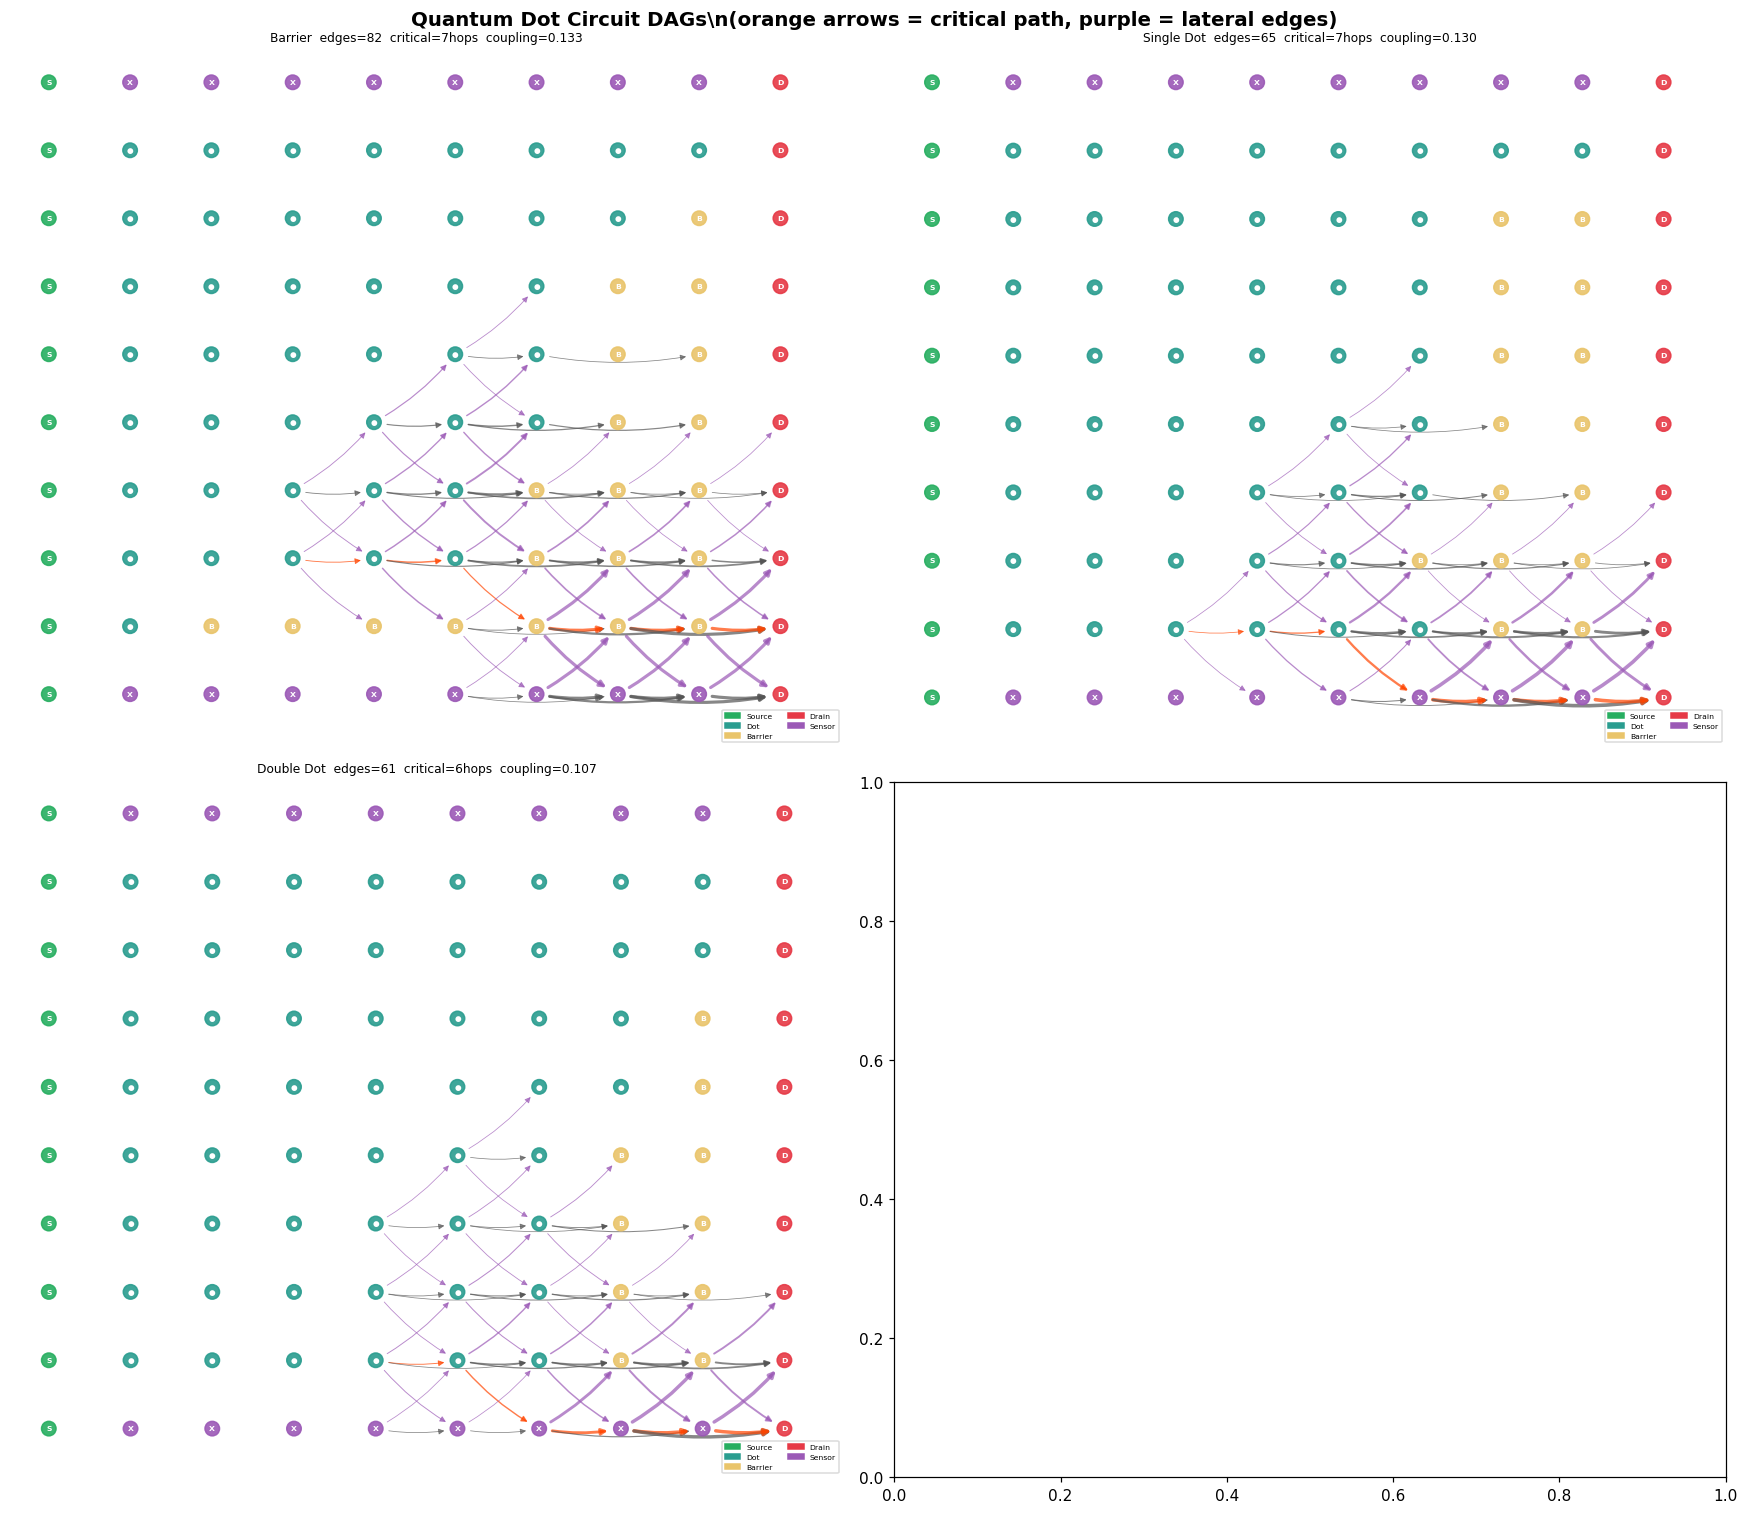

In [15]:
def draw_dag(G, ax, title="", highlight_path=None):
    pos = {nid: (d['col'], -(d['row'])) for nid,d in G.nodes(data=True)}
    ntypes = nx.get_node_attributes(G,'type')
    ncolors = [NODE_COLORS.get(ntypes.get(n,'dot'),'#aaa') for n in G.nodes()]
    edges   = list(G.edges(data=True))
    ewidths = [max(0.5, d.get('weight',0.1)*8) for _,_,d in edges]
    ecolors = []
    hp_set  = set(zip(highlight_path, highlight_path[1:])) if highlight_path else set()
    for u,v,d in edges:
        if (u,v) in hp_set:         ecolors.append('#ff4500')
        elif d.get('edge_type')=='lateral': ecolors.append('#9b59b6')
        else:                       ecolors.append('#555')

    nx.draw_networkx_nodes(G,pos,ax=ax,node_color=ncolors,node_size=90,alpha=0.9)
    nx.draw_networkx_edges(G,pos,ax=ax,width=ewidths,edge_color=ecolors,
                           arrows=True,arrowsize=8,arrowstyle='-|>',
                           connectionstyle='arc3,rad=0.1',alpha=0.7,
                           min_source_margin=6,min_target_margin=6)
    abbr = {"source":"S","drain":"D","dot":"●","barrier":"B","sensor":"X"}
    nx.draw_networkx_labels(G,pos,
        labels={n:abbr.get(ntypes.get(n,'dot'),'?') for n in G.nodes()},
        ax=ax,font_size=5,font_color='white',font_weight='bold')
    ax.set_title(title,fontsize=8); ax.axis('off')
    patches=[mpatches.Patch(color=c,label=t.capitalize())
             for t,c in NODE_COLORS.items()]
    ax.legend(handles=patches,fontsize=5,loc='lower right',ncol=2,framealpha=0.7)

fig,axes=plt.subplots(2,2,figsize=(16,14))
fig.suptitle("Quantum Dot Circuit DAGs\\n(orange arrows = critical path, purple = lateral edges)",
             fontsize=13,fontweight="bold")
for ax,cls_idx in zip(axes.flatten(),ALL_LABELS):
    idx=int(np.where(labels==cls_idx)[0][0])
    G=dag_list[idx]; m=analyse_dag(G)
    draw_dag(G,ax,
             title=(f"{LABEL_NAMES[cls_idx]}  "
                    f"edges={G.number_of_edges()}  "
                    f"critical={m['critical_path_len']}hops  "
                    f"coupling={m['mean_coupling']:.3f}"),
             highlight_path=m['longest_path'])
plt.tight_layout()
plt.show(); plt.close(fig)

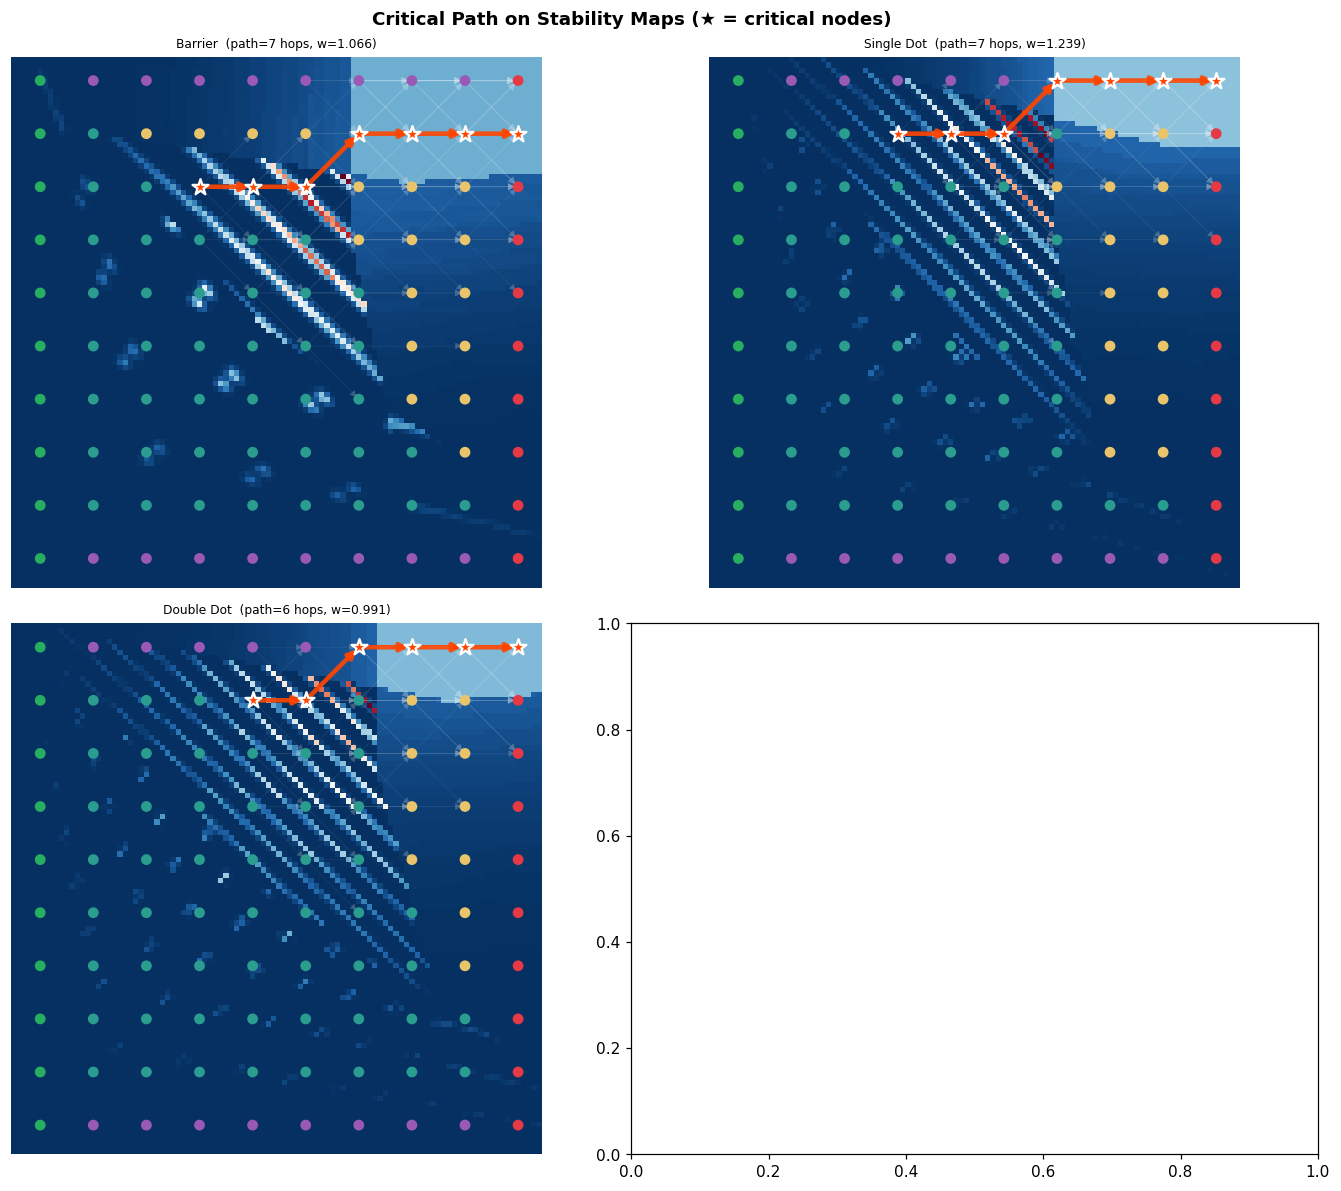

In [17]:
def overlay_dag_on_map(cur_map, G, ax, critical_path=None, title=""):
    bh=bw=100//GRID_N
    ax.imshow(np.log1p(np.abs(cur_map)),cmap='RdBu_r',origin='lower')
    ntypes=nx.get_node_attributes(G,'type')
    for u,v,d in G.edges(data=True):
        r1,c1=u//GRID_N,u%GRID_N; r2,c2=v//GRID_N,v%GRID_N
        x1,y1=c1*bw+bw//2,r1*bh+bh//2
        x2,y2=c2*bw+bw//2,r2*bh+bh//2
        ax.annotate("",xy=(x2,y2),xytext=(x1,y1),
                    arrowprops=dict(arrowstyle="-|>",color='white',
                                   alpha=0.2,lw=d.get('weight',0.1)*3))
    if critical_path:
        for i in range(len(critical_path)-1):
            u=critical_path[i]; v=critical_path[i+1]
            r1,c1=u//GRID_N,u%GRID_N; r2,c2=v//GRID_N,v%GRID_N
            ax.annotate("",xy=(c2*bw+bw//2,r2*bh+bh//2),
                        xytext=(c1*bw+bw//2,r1*bh+bh//2),
                        arrowprops=dict(arrowstyle="-|>",
                                       color='#ff4500',alpha=0.9,lw=3))
    for nid,data in G.nodes(data=True):
        r,c=data['row'],data['col']
        px,py=c*bw+bw//2,r*bh+bh//2
        clr=NODE_COLORS.get(ntypes.get(nid,'dot'),'#aaa')
        is_cp=critical_path and nid in critical_path
        ax.scatter(px,py,c='#ff4500' if is_cp else clr,
                   s=120 if is_cp else 50,
                   edgecolors='white' if is_cp else 'none',
                   linewidths=1.5,zorder=6,
                   marker='*' if is_cp else 'o')
    ax.set_title(title,fontsize=8); ax.axis('off')

fig,axes=plt.subplots(2,2,figsize=(13,11))
fig.suptitle("Critical Path on Stability Maps (★ = critical nodes)",
             fontsize=12,fontweight="bold")
for ax,cls_idx in zip(axes.flatten(),ALL_LABELS):
    idx=int(np.where(labels==cls_idx)[0][0])
    G=dag_list[idx]; m=analyse_dag(G)
    overlay_dag_on_map(current[idx],G,ax,
        critical_path=m['longest_path'],
        title=f"{LABEL_NAMES[cls_idx]}  "
              f"(path={m['critical_path_len']} hops, w={m['critical_path_weight']:.3f})")
plt.tight_layout()
plt.show(); plt.close(fig)

In [18]:
import pandas as pd
print("Computing metrics for all DAGs ...")
rows=[]
for i,(G,lbl) in enumerate(zip(dag_list,labels)):
    m=analyse_dag(G)
    rows.append({'label':lbl,'n_edges':G.number_of_edges(),
                 'critical_path':m['critical_path_len'],
                 'dag_width':m['dag_width'],
                 'n_sources':m['n_sources'],'n_sinks':m['n_sinks'],
                 'mean_coupling':m['mean_coupling'],
                 'max_coupling':m['max_coupling'],
                 'max_out_degree':m['max_out_degree']})
df=pd.DataFrame(rows)


Computing metrics for all DAGs ...


In [19]:
print("\\nMean DAG metrics by class:")
print(df.groupby('label')[['n_edges','critical_path','dag_width',
                            'mean_coupling']].mean().round(3).to_string())

\nMean DAG metrics by class:
       n_edges  critical_path  dag_width  mean_coupling
label                                                  
0       81.833          6.222       10.0          0.152
1       48.913          5.245       10.0          0.099
2       55.344          5.604       10.0          0.111


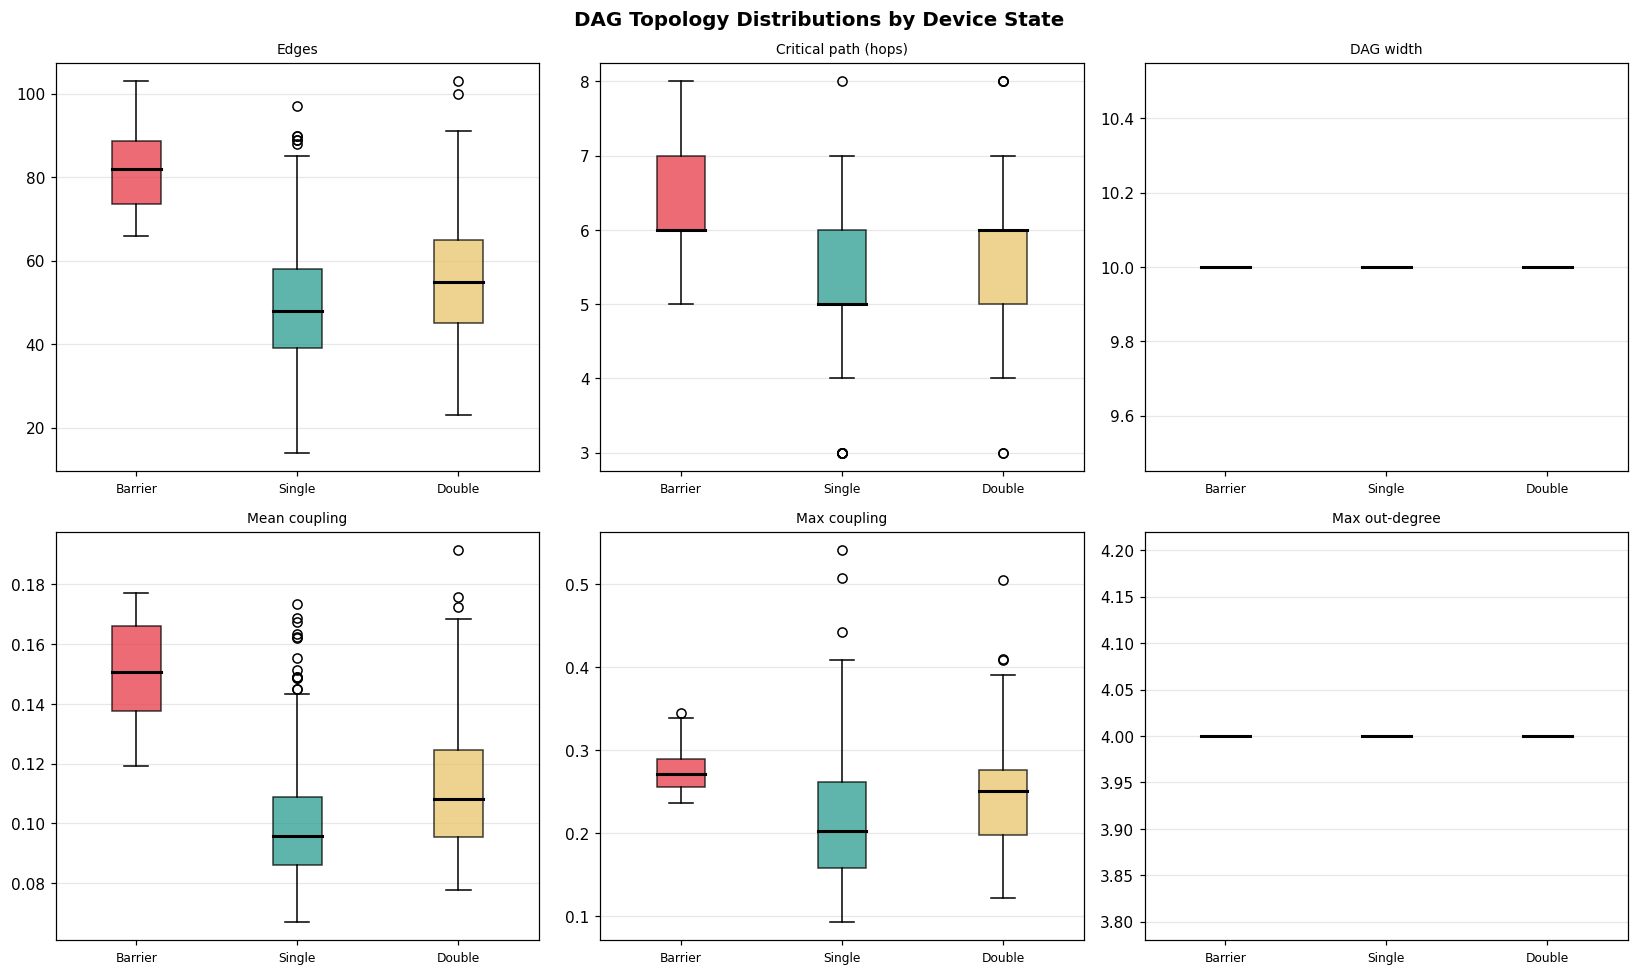

In [20]:
fig,axes=plt.subplots(2,3,figsize=(15,9))
fig.suptitle("DAG Topology Distributions by Device State",
             fontsize=13,fontweight="bold")
metrics_plot=[('n_edges','Edges'),('critical_path','Critical path (hops)'),
              ('dag_width','DAG width'),('mean_coupling','Mean coupling'),
              ('max_coupling','Max coupling'),('max_out_degree','Max out-degree')]
for ax,(col,title) in zip(axes.flatten(),metrics_plot):
    data=[df[df['label']==k][col].values for k in ALL_LABELS]
    bp=ax.boxplot(data,patch_artist=True,medianprops={'color':'black','lw':2})
    for patch,color in zip(bp['boxes'],PALETTE):
        patch.set_facecolor(color); patch.set_alpha(0.75)
    ax.set_xticks(range(1,N_CLASSES+1))
    ax.set_xticklabels([n.split()[0] for n in CLASS_NAMES],fontsize=8)
    ax.set_title(title,fontsize=9); ax.grid(axis='y',alpha=0.3)
plt.tight_layout()
plt.show(); plt.close(fig)

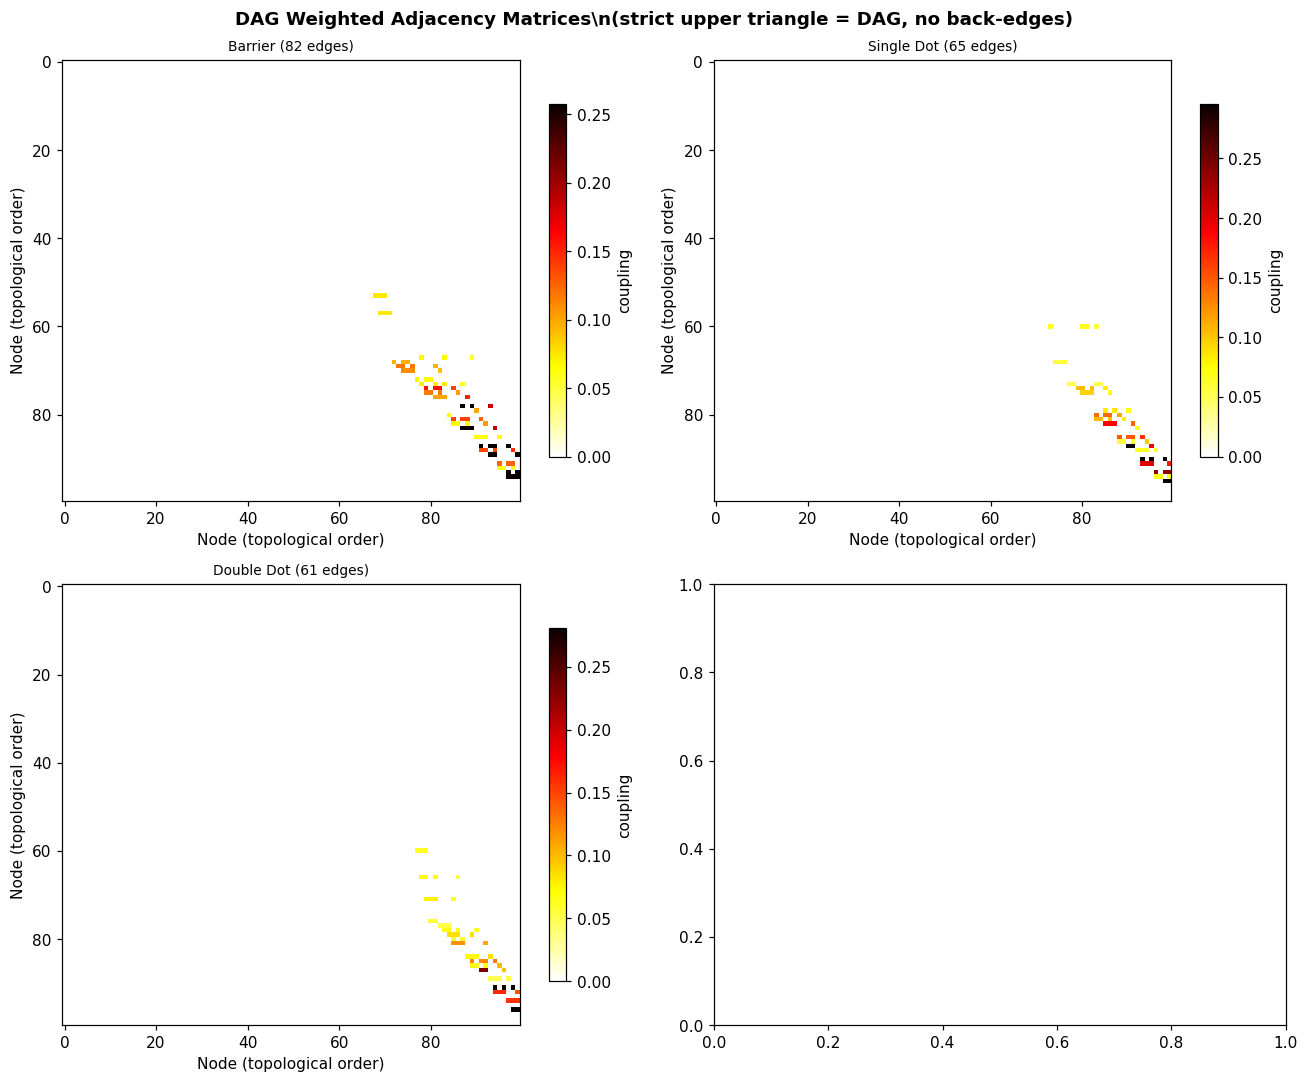

In [21]:
fig,axes=plt.subplots(2,2,figsize=(12,10))
fig.suptitle("DAG Weighted Adjacency Matrices\\n"
             "(strict upper triangle = DAG, no back-edges)",
             fontsize=12,fontweight="bold")
for ax,cls_idx in zip(axes.flatten(),ALL_LABELS):
    idx=int(np.where(labels==cls_idx)[0][0])
    G=dag_list[idx]
    topo={nid:i for i,nid in enumerate(nx.topological_sort(G))}
    n=len(topo); A=np.zeros((n,n))
    for u,v,d in G.edges(data=True):
        A[topo[u],topo[v]]=d.get('weight',1.0)
    im=ax.imshow(A,cmap='hot_r',vmin=0,vmax=A.max(),aspect='auto')
    plt.colorbar(im,ax=ax,shrink=0.8,label='coupling')
    ax.set_title(f"{LABEL_NAMES[cls_idx]} ({G.number_of_edges()} edges)",fontsize=9)
    ax.set_xlabel("Node (topological order)")
    ax.set_ylabel("Node (topological order)")
plt.tight_layout()
plt.show(); plt.close(fig)

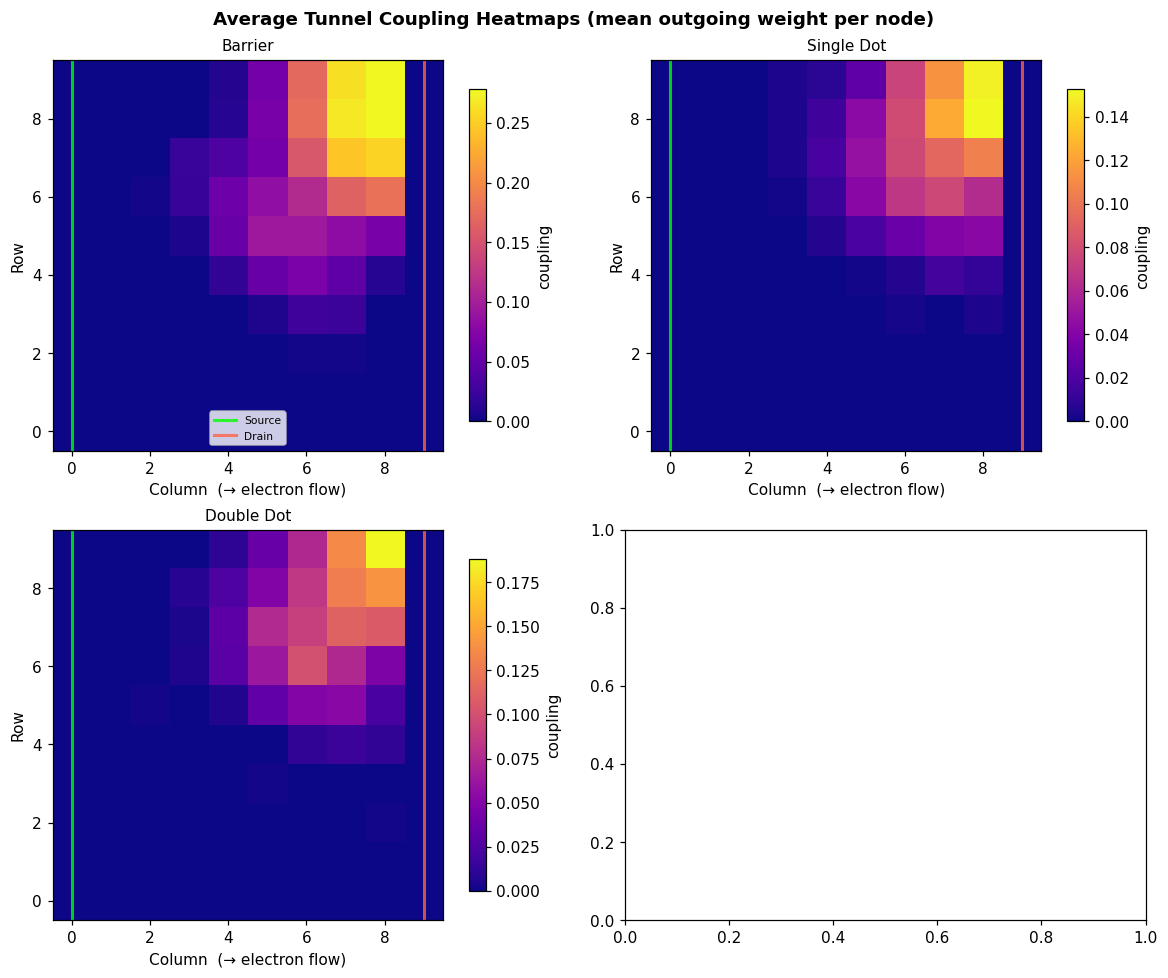

In [22]:
def coupling_heatmap(G):
    mat=np.zeros((GRID_N,GRID_N))
    for nid,data in G.nodes(data=True):
        oe=list(G.out_edges(nid,data=True))
        if oe: mat[data['row'],data['col']]=np.mean([d['weight'] for _,_,d in oe])
    return mat

fig,axes=plt.subplots(2,2,figsize=(11,9))
fig.suptitle("Average Tunnel Coupling Heatmaps (mean outgoing weight per node)",
             fontsize=12,fontweight="bold")
for ax,cls_idx in zip(axes.flatten(),ALL_LABELS):
    cls_idxs=np.where(labels==cls_idx)[0][:30]
    avg=np.mean([coupling_heatmap(dag_list[i]) for i in cls_idxs],axis=0)
    im=ax.imshow(avg,cmap='plasma',origin='lower',vmin=0)
    plt.colorbar(im,ax=ax,shrink=0.85,label='coupling')
    ax.set_title(LABEL_NAMES[cls_idx],fontsize=10)
    ax.set_xlabel("Column  (→ electron flow)"); ax.set_ylabel("Row")
    ax.axvline(0,color='lime',lw=2,alpha=0.8,label='Source')
    ax.axvline(GRID_N-1,color='tomato',lw=2,alpha=0.8,label='Drain')
    if cls_idx==0: ax.legend(fontsize=7)
plt.tight_layout()
plt.show(); plt.close(fig)

In [23]:
def dag_to_pyg(G, graph_label):
    nodes   = list(G.nodes())
    id_map  = {nid:i for i,nid in enumerate(nodes)}
    feats   = []
    for nid in nodes:
        d=G.nodes[nid]
        oh=[0.0]*len(NODE_TYPES)
        t=d.get('type_id',1)
        if 0<=t<len(NODE_TYPES): oh[t]=1.0
        feats.append([
            d.get('current_mean',0.0), d.get('current_std',0.0),
            d.get('sensor_mean',0.0),  d.get('charge_mean',0.0),
            d.get('norm_row',0.0),     d.get('norm_col',0.0),
            float(G.in_degree(nid))/max(GRID_N,1),
            float(G.out_degree(nid))/max(GRID_N,1),
        ]+oh)
    x=torch.tensor(feats,dtype=torch.float)
    srcs,dsts,wts=[],[],[]
    for u,v,d in G.edges(data=True):
        srcs.append(id_map[u]); dsts.append(id_map[v])
        wts.append(d.get('weight',1.0))
    if srcs:
        ei=torch.tensor([srcs,dsts],dtype=torch.long)
        ea=torch.tensor(wts,dtype=torch.float).unsqueeze(1)
    else:
        ei=torch.zeros((2,0),dtype=torch.long)
        ea=torch.zeros((0,1),dtype=torch.float)
    return Data(x=x,edge_index=ei,edge_attr=ea,
                y=torch.tensor(graph_label,dtype=torch.long))

print("Converting to PyG")
pyg_list=[dag_to_pyg(G,int(lbl)) for G,lbl in zip(dag_list,labels)]
IN_DIM=pyg_list[0].x.shape[1]
d0=pyg_list[0]
print(f"PyG graphs: {len(pyg_list)}  |  Node features: {IN_DIM}")
print(f"Example: nodes={d0.num_nodes}  edges={d0.num_edges}  "
      f"label={d0.y.item()} ({LABEL_NAMES[d0.y.item()]})")

Converting to PyG
PyG graphs: 1001  |  Node features: 13
Example: nodes=100  edges=65  label=1 (Single Dot)


In [24]:
class DAGConv(nn.Module):
    def __init__(self,in_dim,out_dim):
        super().__init__()
        self.lin_self =nn.Linear(in_dim,out_dim)
        self.lin_neigh=nn.Linear(in_dim,out_dim)
        self.bn=nn.BatchNorm1d(out_dim)
    def forward(self,x,edge_index,edge_attr=None):
        src,dst=edge_index
        msgs=self.lin_neigh(x[src])
        if edge_attr is not None: msgs=msgs*edge_attr
        agg=torch.zeros(x.size(0),msgs.size(1),device=x.device,dtype=x.dtype)
        agg.scatter_add_(0,dst.unsqueeze(1).expand_as(msgs),msgs)
        return self.bn(F.relu(self.lin_self(x)+agg))

class DAGClassifier(nn.Module):
    def __init__(self,in_dim,hidden_dim,n_classes,n_layers=N_LAYERS,dropout=DROPOUT):
        super().__init__()
        self.dropout=dropout
        self.convs=nn.ModuleList([
            DAGConv(in_dim if i==0 else hidden_dim, hidden_dim)
            for i in range(n_layers)])
        self.head=nn.Sequential(
            nn.Linear(hidden_dim*2,hidden_dim),nn.ReLU(),nn.Dropout(dropout),
            nn.Linear(hidden_dim,hidden_dim//2),nn.ReLU(),nn.Dropout(dropout),
            nn.Linear(hidden_dim//2,n_classes))
    def forward(self,x,edge_index,edge_attr,batch):
        for conv in self.convs:
            x=conv(x,edge_index,edge_attr)
            x=F.dropout(x,p=self.dropout,training=self.training)
        return self.head(torch.cat([global_mean_pool(x,batch),
                                    global_max_pool(x,batch)],dim=1))

model=DAGClassifier(IN_DIM,HIDDEN_DIM,N_CLASSES).to(device)
n_p=sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"DAGClassifier: {n_p:,} parameters")
# shape test
d=pyg_list[0]
out=model(d.x.to(device),d.edge_index.to(device),
          d.edge_attr.to(device) if d.edge_attr is not None
          else torch.ones(d.num_edges,1).to(device),
          torch.zeros(d.num_nodes,dtype=torch.long).to(device))
print(f"Output shape: {out.shape}  (expect [1,{N_CLASSES}])")

DAGClassifier: 29,251 parameters
Output shape: torch.Size([1, 3])  (expect [1,3])


In [25]:
all_y=[g.y.item() for g in pyg_list]
tr_graphs,te_graphs=train_test_split(pyg_list,test_size=TEST_SIZE,
    random_state=SEED,stratify=all_y)
tr_loader=GeoLoader(tr_graphs,batch_size=BATCH_SIZE,shuffle=True)
te_loader=GeoLoader(te_graphs,batch_size=BATCH_SIZE,shuffle=False)
print(f"Train: {len(tr_graphs)}  |  Test: {len(te_graphs)}")

optimizer=Adam(model.parameters(),lr=LR,weight_decay=1e-4)
scheduler=CosineAnnealingLR(optimizer,T_max=N_EPOCHS,eta_min=1e-5)
criterion=nn.CrossEntropyLoss()
history={"trl":[],"tel":[],"tra":[],"tea":[]}
best_acc=0.0; best_state=None; t0=time.time()

print(f"Training for {N_EPOCHS} epochs ...")
for epoch in range(1,N_EPOCHS+1):
    model.train()
    tl=tc=tt=0
    for b in tr_loader:
        b=b.to(device)
        ea=b.edge_attr if b.edge_attr is not None \
           else torch.ones(b.num_edges,1,device=device)
        optimizer.zero_grad()
        out=model(b.x,b.edge_index,ea,b.batch)
        loss=criterion(out,b.y); loss.backward(); optimizer.step()
        tl+=loss.item()*b.num_graphs
        tc+=(out.argmax(1)==b.y).sum().item(); tt+=b.num_graphs
    scheduler.step()
    model.eval(); el=ec=et=0; pa=[]; la=[]
    with torch.no_grad():
        for b in te_loader:
            b=b.to(device)
            ea=b.edge_attr if b.edge_attr is not None \
               else torch.ones(b.num_edges,1,device=device)
            out=model(b.x,b.edge_index,ea,b.batch)
            loss=criterion(out,b.y)
            el+=loss.item()*b.num_graphs; pred=out.argmax(1)
            ec+=(pred==b.y).sum().item(); et+=b.num_graphs
            pa.extend(pred.cpu().tolist()); la.extend(b.y.cpu().tolist())
    ta,tea=tc/tt,ec/et
    history["trl"].append(tl/tt); history["tel"].append(el/et)
    history["tra"].append(ta); history["tea"].append(tea)
    if tea>best_acc:
        best_acc=tea
        best_state={k:v.clone() for k,v in model.state_dict().items()}
        best_preds=pa; best_labels=la
    if epoch%20==0 or epoch==1:
        print(f"  Epoch {epoch:4d}/{N_EPOCHS} | Train:{ta*100:.1f}%  "
              f"Test:{tea*100:.1f}%  loss:{el/et:.4f}")

model.load_state_dict(best_state)
print(f"\\nBest test accuracy: {best_acc*100:.2f}%  | Time: {time.time()-t0:.1f}s")

Train: 800  |  Test: 201
Training for 100 epochs ...
  Epoch    1/100 | Train:72.4%  Test:75.6%  loss:0.9303
  Epoch   20/100 | Train:86.9%  Test:82.6%  loss:0.3346
  Epoch   40/100 | Train:88.8%  Test:86.6%  loss:0.2628
  Epoch   60/100 | Train:90.4%  Test:93.0%  loss:0.2066
  Epoch   80/100 | Train:91.6%  Test:91.0%  loss:0.2170
  Epoch  100/100 | Train:92.0%  Test:90.5%  loss:0.2305
\nBest test accuracy: 93.53%  | Time: 375.2s


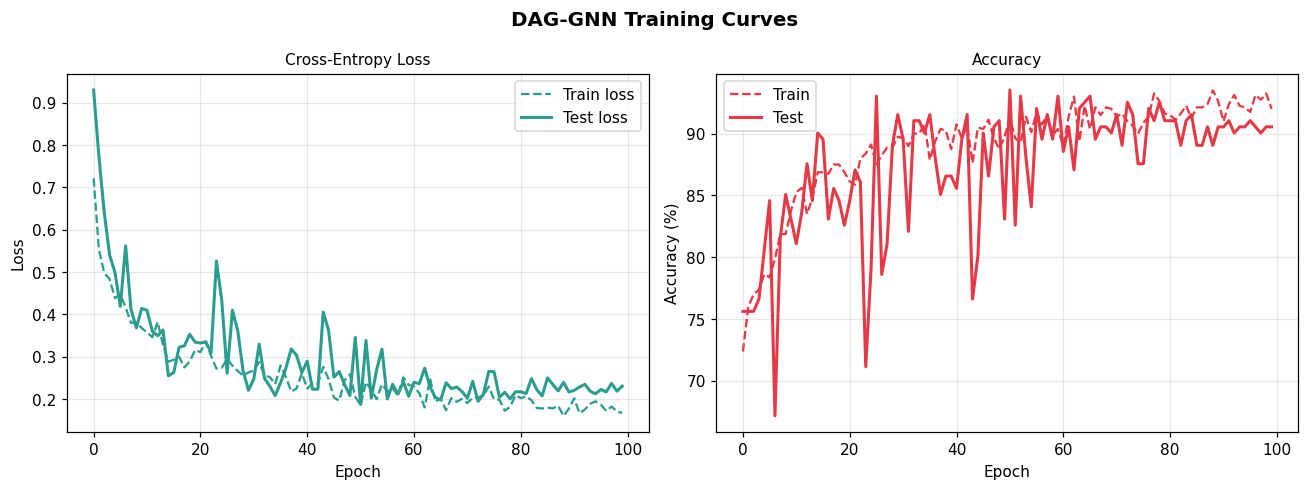

In [26]:
fig,(a1,a2)=plt.subplots(1,2,figsize=(12,4.5))
fig.suptitle("DAG-GNN Training Curves",fontsize=13,fontweight="bold")
a1.plot(history["trl"],lw=1.5,ls="--",color="#2a9d8f",label="Train loss")
a1.plot(history["tel"],lw=2.0,color="#2a9d8f",label="Test loss")
a1.set_xlabel("Epoch"); a1.set_ylabel("Loss")
a1.set_title("Cross-Entropy Loss"); a1.legend(); a1.grid(alpha=0.3)
a2.plot(np.array(history["tra"])*100,lw=1.5,ls="--",color="#e63946",label="Train")
a2.plot(np.array(history["tea"])*100,lw=2.0,color="#e63946",label="Test")
a2.set_xlabel("Epoch"); a2.set_ylabel("Accuracy (%)")
a2.set_title("Accuracy"); a2.legend(); a2.grid(alpha=0.3)
plt.tight_layout()
plt.show(); plt.close(fig)

In [27]:
print(f"\\nBest test accuracy: {best_acc*100:.2f}%")
print("\\nClassification Report:")
print(classification_report(best_labels,best_preds,
      labels=ALL_LABELS,target_names=CLASS_NAMES,zero_division=0))

\nBest test accuracy: 93.53%
\nClassification Report:
              precision    recall  f1-score   support

     Barrier       1.00      0.75      0.86         4
  Single Dot       0.98      0.94      0.96       152
  Double Dot       0.81      0.93      0.87        45

    accuracy                           0.94       201
   macro avg       0.93      0.87      0.89       201
weighted avg       0.94      0.94      0.94       201



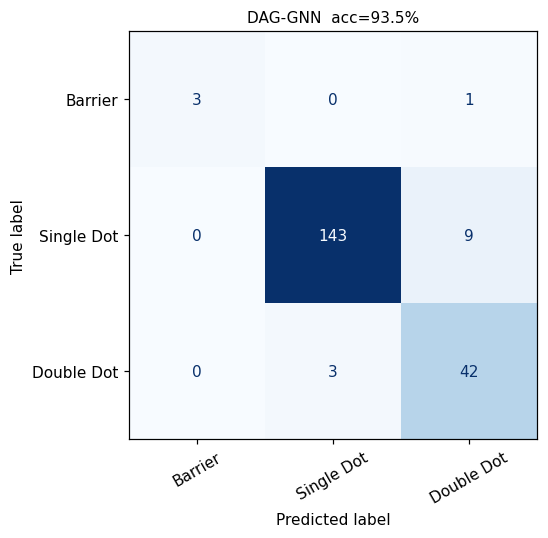

In [28]:
cm=confusion_matrix(best_labels,best_preds,labels=ALL_LABELS)
fig2,ax=plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(cm,display_labels=CLASS_NAMES).plot(
    ax=ax,cmap="Blues",colorbar=False,xticks_rotation=30)
ax.set_title(f"DAG-GNN  acc={best_acc*100:.1f}%")
plt.tight_layout()
plt.show(); plt.close(fig2)

In [29]:
print(f"  Grid          : {GRID_N}x{GRID_N} = {GRID_N**2} nodes/device")
print(f"  Edge direction: left→right (col_src < col_dst)")
print(f"  Coupling thr  : {COUPLING_THR}")
print(f"  Total DAGs    : {len(dag_list)}")
print(f"  Node feat dim : {IN_DIM}")
print(f"  GNN layers    : {N_LAYERS}  hidden={HIDDEN_DIM}")
print(f"  Best acc      : {best_acc*100:.2f}%")
print("\\n  Mean topology by class:")
for cls_idx in ALL_LABELS:
    cls_df=df[df['label']==cls_idx]
    print(f"  {LABEL_NAMES[cls_idx]:<15} "
          f"edges={cls_df['n_edges'].mean():.1f}  "
          f"crit_path={cls_df['critical_path'].mean():.1f}  "
          f"coupling={cls_df['mean_coupling'].mean():.4f}")

  Grid          : 10x10 = 100 nodes/device
  Edge direction: left→right (col_src < col_dst)
  Coupling thr  : 0.05
  Total DAGs    : 1001
  Node feat dim : 13
  GNN layers    : 3  hidden=64
  Best acc      : 93.53%
\n  Mean topology by class:
  Barrier         edges=81.8  crit_path=6.2  coupling=0.1517
  Single Dot      edges=48.9  crit_path=5.2  coupling=0.0989
  Double Dot      edges=55.3  crit_path=5.6  coupling=0.1111
